# 08 - Tuning Last, and a Correction for the Logarithm

Two steps remain on the plan, and they are the two that people usually do
first.

**Step 8 is the hyperparameter search.** We have not touched the settings of
XGBoost since notebook 03: a learning rate of 0.05, trees of depth 8, and a
few more numbers chosen as a reasonable start. Every gain so far came from
somewhere else - the logarithm, the store groups, the closed days. That is the
reason tuning comes last. Done early, it would have made every later
experiment slower, and the settings would have been tuned for a model that no
longer exists. Done now, it works on the final feature set, once.

The expected gain is small, a few thousandths. But notebook 07 left a real
question open: a learning rate of 0.1 cost 0.002 there, so the rate deserves
a choice and not a guess.

**Step 9 is the calibration.** The model learns the logarithm of the sales
and we undo the logarithm at the end. The mean of logarithms sits below the
logarithm of the mean, so the predictions come back a little low. Notebook 05
measured it: the median error is -1.3 percent, and it is between -1.1 and
-1.4 in every segment. One multiplicative correction should take almost all of
it, and it costs no training at all.

**The budget.** Notebook 07 set the rule: screen cheaply, confirm once. The
search ranks eight settings on one window and one seed, in about seven
minutes. Only the winner is confirmed with three seeds on four windows. The
base is not run again: it is the model of notebook 06, measured there under
exactly this protocol, and its four numbers are the bar. The calibration is
arithmetic on the rows the confirmation produces.

In [1]:
import sys
import time
from datetime import timedelta
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
from src.data_loader import DataLoader
from src.features import FeatureBuilder, build_closure_calendar
from src.model import SalesModel, DEFAULT_PARAMS
from src.segments import StoreSegmenter
from src.validation import RollingOriginSplit
from src.metrics import rmspe

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
pl.Config.set_tbl_rows(20)

loader = DataLoader(PROJECT_ROOT / "data")
df = loader.load()
closure = build_closure_calendar(loader.load(drop_closed=False))
folds = list(RollingOriginSplit(n_splits=4).split(df))

# The bar: the model of notebook 06 on the four windows, three seeds each.
BASE = np.array([0.1657, 0.0998, 0.0999, 0.1102])
print("Open days:", f"{df.height:,}")
print("The bar, notebook 06:", " ".join(f"{v:.4f}" for v in BASE), f"  mean={BASE.mean():.4f}")

Open days: 844,392
The bar, notebook 06: 0.1657 0.0998 0.0999 0.1102   mean=0.1189


## The search

Eight settings, ranked on one window. We take the newest window, fold 4, and
cut the last six weeks off its training rows: that is the **inner window**,
the same one `SalesModel` uses to count its trees. Everything is fitted on
the rows before the cut - the store statistics, the segments, the model -
and scored on the six weeks after it. The validation rows of fold 4 are not
touched, and the other three windows are not touched at all.

Two things are worth saying before the numbers. First, the same six weeks
stop the training and score it, so every number below is a little friendly.
That is fine for a ranking and not fine for a decision, which is why nothing
is accepted from this table. Second, the settings are chosen by hand and
they cover one question well: how deep should the trees be, and how fast
should they learn. Two of the eight also test a stronger regularisation.
Early stopping waits 30 rounds instead of 50 from here on; at these learning
rates that is enough patience.

In [2]:
SEGMENTS = [1, 2, 3, 4]
PATIENCE = 30

# Each setting starts from the model of notebook 03 and changes a few numbers.
CONFIGS = {
    "current (eta .05, depth 8)": dict(),
    "eta .10, depth 8": dict(eta=0.1),
    "eta .05, depth 6": dict(max_depth=6),
    "eta .05, depth 10": dict(max_depth=10),
    "eta .10, depth 6": dict(eta=0.1, max_depth=6),
    "eta .10, depth 10": dict(eta=0.1, max_depth=10),
    "eta .05, depth 8, stronger reg.": dict(min_child_weight=20, subsample=0.8),
    "eta .05, depth 10, fewer columns": dict(max_depth=10, min_child_weight=20,
                                             colsample_bytree=0.6),
}

# The inner window of fold 4: the last six weeks of its training rows.
train4 = folds[3].train
cut = train4["Date"].max() - timedelta(days=42)
inner_train = train4.filter(pl.col("Date") <= cut)
inner_valid = train4.filter(pl.col("Date") > cut)

builder = FeatureBuilder(calendar=closure, with_easter=True).fit(inner_train)
segmenter = StoreSegmenter(n_segments=4).fit(inner_train)
tr = segmenter.transform(builder.transform(inner_train))
va = segmenter.transform(builder.transform(inner_valid))
print(f"Inner window: {inner_valid['Date'].min()} to {inner_valid['Date'].max()}, "
      f"{inner_valid.height:,} rows")


def rank_one(changes, seed=42):
    """Train the four segment models on the inner window and score it."""
    params = dict(DEFAULT_PARAMS, seed=seed, **changes)
    parts, trees = [], []
    for s in SEGMENTS:
        tr_s, va_s = tr.filter(pl.col("segment") == s), va.filter(pl.col("segment") == s)
        # refit=False keeps the model of the inner window instead of
        # training again on everything. That is all a ranking needs.
        model = SalesModel(params=params, early_stopping_rounds=PATIENCE,
                           refit=False).fit(tr_s, builder.feature_names_)
        parts.append(va_s.with_columns(pl.Series("prediction", model.predict(va_s))))
        trees.append(model.best_rounds_)
    out = pl.concat(parts)
    return rmspe(out["Sales"], out["prediction"]), trees

Inner window: 2015-05-09 to 2015-06-19, 37,473 rows


In [3]:
rows = []
for name, changes in CONFIGS.items():
    started = time.perf_counter()
    score, trees = rank_one(changes)
    rows.append({"setting": name, "inner rmspe": round(score, 4),
                 "trees": int(np.mean(trees)), "seconds": int(time.perf_counter() - started)})
    print(f"{name:<36} {score:.4f}   {rows[-1]['trees']:>4} trees   {rows[-1]['seconds']:>3} s")

ranking = pl.DataFrame(rows).sort("inner rmspe")
winner = ranking["setting"][0]
print(f"\nWinner of the ranking: {winner}")

current (eta .05, depth 8)           0.1021    642 trees    22 s


eta .10, depth 8                     0.1059    231 trees     8 s


eta .05, depth 6                     0.1058    824 trees    21 s


eta .05, depth 10                    0.1033    363 trees    53 s


eta .10, depth 6                     0.1103    433 trees    62 s


eta .10, depth 10                    0.1050    156 trees    47 s


eta .05, depth 8, stronger reg.      0.1082    472 trees    80 s


eta .05, depth 10, fewer columns     0.1049    434 trees   107 s

Winner of the ranking: current (eta .05, depth 8)


## The confirmation

The winner is trained the way every accepted model was trained: three seeds,
four windows, one model per segment, the tree count chosen on each window's
own inner cut. The seeds after the first reuse the tree count, as in
notebook 07. The bar is the model of notebook 06, and the rule is the rule of
the whole project: the winner stays only if it is better on every window by
more than the seed noise.

If the ranking picked the current settings, this cell simply reproduces
notebook 06 and gives us the scored rows that the calibration needs.

In [4]:
SEEDS = [42, 7, 2024]
WINNER = dict(DEFAULT_PARAMS, **CONFIGS[winner])


def fit_predict(seed, fold, rounds=None):
    """One model per segment on one window. Returns the scored validation
    rows, the tree count per segment, and the scored inner window."""
    builder = FeatureBuilder(calendar=closure, with_easter=True).fit(fold.train)
    segmenter = StoreSegmenter(n_segments=4).fit(fold.train)
    tr = segmenter.transform(builder.transform(fold.train))
    va = segmenter.transform(builder.transform(fold.valid))
    parts, inner, used = [], [], {}
    for s in SEGMENTS:
        tr_s, va_s = tr.filter(pl.col("segment") == s), va.filter(pl.col("segment") == s)
        if va_s.height == 0:
            continue
        model = SalesModel(params=dict(WINNER, seed=seed), early_stopping_rounds=PATIENCE,
                           fixed_rounds=None if rounds is None else rounds[s])
        model.fit(tr_s, builder.feature_names_)
        used[s] = model.best_rounds_
        parts.append(va_s.with_columns(pl.Series("prediction", model.predict(va_s))))
        if model.inner_scored_ is not None:
            inner.append(model.inner_scored_)
    return pl.concat(parts), used, (pl.concat(inner) if inner else None)


KEEP = ["Store", "Date", "segment", "Sales", "prediction"]
started = time.perf_counter()
grid = np.zeros((len(SEEDS), len(folds)))
kept, inner_kept, rounds = [], {}, {}
for i, seed in enumerate(SEEDS):
    for j, fold in enumerate(folds):
        out, used, inner = fit_predict(seed, fold, rounds.get(j))
        rounds.setdefault(j, used)
        grid[i, j] = rmspe(out["Sales"], out["prediction"])
        kept.append(out.select(KEEP).with_columns(
            pl.lit(fold.index).alias("fold"), pl.lit(seed).alias("seed")))
        if inner is not None:
            inner_kept[fold.index] = inner.select(KEEP)
kept = pl.concat(kept)

winner_folds = grid.mean(axis=0)
noise = grid.mean(axis=1).std()
delta = winner_folds - BASE
print(f"{'notebook 06':<28} " + " ".join(f"{v:.4f}" for v in BASE) + f"   mean={BASE.mean():.4f}")
print(f"{winner:<28} " + " ".join(f"{v:.4f}" for v in winner_folds)
      + f"   mean={grid.mean():.4f}   seed noise={noise:.4f}")
print(f"{'difference':<28} " + " ".join(f"{v:+.4f}" for v in delta)
      + f"   mean={delta.mean():+.4f}   better on {int((delta < 0).sum())}/4, "
      f"by more than the noise on {int((delta < -noise).sum())}/4")
print(f"\n{time.perf_counter() - started:.0f} seconds")

notebook 06                  0.1657 0.0998 0.0999 0.1102   mean=0.1189
current (eta .05, depth 8)   0.1698 0.1000 0.0992 0.1143   mean=0.1208   seed noise=0.0003
difference                   +0.0041 +0.0002 -0.0007 +0.0041   mean=+0.0019   better on 1/4, by more than the noise on 1/4

1161 seconds


**The current settings win the ranking, and nothing is accepted.**

The search is a clear result. The settings we have used since notebook 03
score 0.1021 on the inner window; the closest challenger, deeper trees at the
same learning rate, is 0.0012 behind and takes two and a half times as long.
Every setting with a learning rate of 0.1 is at least 0.003 behind, which is
the answer to the question notebook 07 left open: the cost of the faster
rate was real, and the slower rate stays. Stronger regularisation only hurts.
So the search has nothing to add, and that is a finding, not a failure: the
starting values were sensible, and every gain of the project came from the
data and the features, not from the knobs.

The confirmation deserves a careful reading. It trains the same settings as
notebook 06 and lands at 0.1208 instead of 0.1189 - the same on two windows,
0.004 worse on the oldest and the newest. Two speed settings of this notebook
are the only difference: early stopping waits 30 rounds instead of 50, and
the second and third seed reuse the tree count of the first. Together they
cost 0.002 on two windows, and this run cannot say which of the two is to
blame. The lesson is worth the price: at a learning rate of 0.05 the
patience of the early stopping is itself a setting, and one that moved the
score more than most of the table above. The model stays exactly as notebook
06 measured it, with the patience of 50.

## The correction for the logarithm

The correction is one number, a factor that multiplies every prediction. For
RMSPE the best factor has a closed form: with `r = prediction / sales`, the
factor is `sum(r) / sum(r squared)`. No fitting, no seeds.

The factor must be learned on rows the model has not seen, and not on the
rows we score. The inner window of each fold is exactly that: the model of
the first seed stops its training there, so it never trained on those six
weeks, and they lie before the validation window in time, as they would in
the real task. So for each window we learn the factor on its inner cut and
apply it to its validation rows, for all three seeds.

Two more numbers put the result in context. A factor per segment tests
whether one number is enough - notebook 05 said it would be, because the
bias is the same in every segment. And a factor learned on the validation
rows themselves is the most the correction could ever give; we cannot use it,
but it says how far the honest factor is from the ceiling.

In [5]:
def best_factor(rows):
    """The multiplier that minimises RMSPE on these rows."""
    rows = rows.filter(pl.col("Sales") > 0)
    r = (rows["prediction"] / rows["Sales"]).to_numpy()
    return float(r.sum() / (r ** 2).sum())


def score_by_fold(rows, pred="prediction"):
    """RMSPE per window, averaged over the seeds."""
    scores = []
    for f in sorted(rows["fold"].unique().to_list()):
        part = rows.filter(pl.col("fold") == f)
        scores.append(np.mean([rmspe(p["Sales"], p[pred])
                               for _, p in part.group_by("seed")]))
    return np.array(scores)


# A global factor per window, learned on the inner cut of that window.
factors = {f: best_factor(inner_kept[f]) for f in inner_kept}
by_segment = {f: {s: best_factor(inner_kept[f].filter(pl.col("segment") == s))
                  for s in SEGMENTS} for f in inner_kept}
ceiling = {f: best_factor(kept.filter(pl.col("fold") == f)) for f in inner_kept}

calibrated = kept.with_columns(
    (pl.col("prediction") * pl.col("fold").replace_strict(factors)).alias("global"),
    (pl.col("prediction") * pl.struct(["fold", "segment"]).map_elements(
        lambda x: by_segment[x["fold"]][x["segment"]], return_dtype=pl.Float64)
     ).alias("per segment"),
    (pl.col("prediction") * pl.col("fold").replace_strict(ceiling)).alias("ceiling"),
)

print("Factor learned on the inner cut of each window:")
for f in sorted(factors):
    seg = " ".join(f"{by_segment[f][s]:.4f}" for s in SEGMENTS)
    print(f"  window {f}: global {factors[f]:.4f}   per segment {seg}   ceiling {ceiling[f]:.4f}")

before = score_by_fold(calibrated)
results = {"no correction": before}
for col in ["global", "per segment", "ceiling"]:
    results[col] = score_by_fold(calibrated, col)
print("\nRMSPE per window, mean of three seeds:")
for name, vals in results.items():
    d = vals - before
    print(f"  {name:<14} " + " ".join(f"{v:.4f}" for v in vals)
          + f"   mean={vals.mean():.4f}   vs none {d.mean():+.4f}   better on {int((d < 0).sum())}/4")

Factor learned on the inner cut of each window:
  window 1: global 0.9687   per segment 0.9354 0.9637 0.9759 0.9890   ceiling 0.9901
  window 2: global 1.0051   per segment 1.0181 1.0128 0.9760 1.0136   ceiling 1.0134
  window 3: global 1.0062   per segment 1.0136 0.9991 1.0167 1.0068   ceiling 1.0088
  window 4: global 1.0100   per segment 1.0125 1.0043 1.0121 1.0102   ceiling 0.9736

RMSPE per window, mean of three seeds:
  no correction  0.1698 0.1000 0.0992 0.1143   mean=0.1208   vs none +0.0000   better on 0/4
  global         0.1708 0.0994 0.0988 0.1172   mean=0.1216   vs none +0.0007   better on 2/4
  per segment    0.1713 0.1006 0.0989 0.1172   mean=0.1220   vs none +0.0012   better on 1/4
  ceiling        0.1695 0.0991 0.0988 0.1111   mean=0.1196   vs none -0.0012   better on 4/4


**The correction is rejected, and the reason is more useful than the number.**

The honest factor, learned on the inner cut of each window, makes the score
worse: 0.1216 against 0.1208, better on two windows and worse on two. The
per-segment version is worse again, as notebook 05 predicted it would be.

The factors themselves say why. On the inner window of the oldest fold the
best factor is 0.969, so the model over-predicts there by three percent;
on the three later folds it is between 1.005 and 1.010, an under-prediction
of about one percent. And the factor that the validation rows would have
wanted is different again - 0.974 on the newest window, where the inner cut
asked for 1.010. The bias is not a constant of the model. It moves from one
six-week block to the next, and it changes sign. A correction learned six
weeks earlier is aimed at a target that has already moved.

The ceiling settles the question. Even the factor learned on the validation
rows themselves, which we could never use, gains only 0.0012. Notebook 05
measured a median error of -1.3 percent and expected more from this step.
The median is not what RMSPE punishes; RMSPE is driven by the large misses,
and a single multiplier does nothing for those. Step 9 is closed, with no
correction.

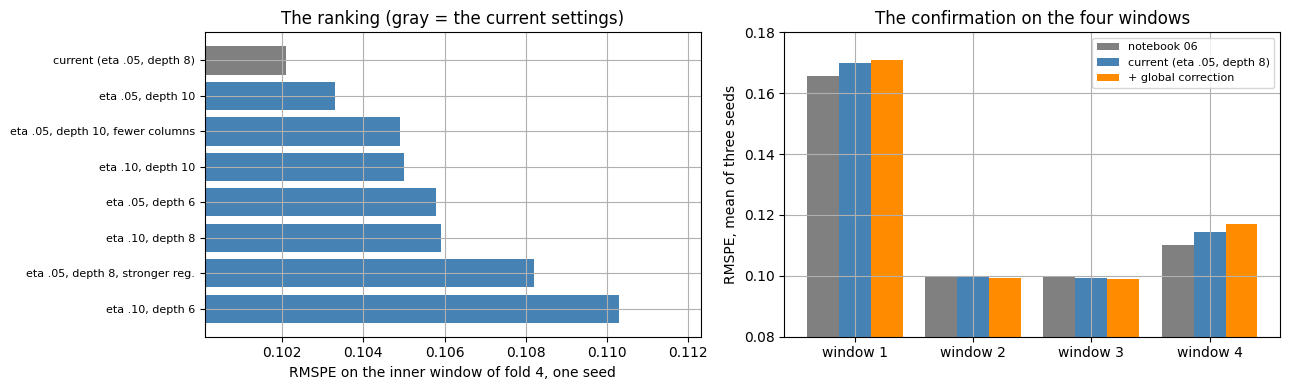

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

names = ranking["setting"].to_list()
vals = ranking["inner rmspe"].to_list()
colors = ["steelblue" if n != "current (eta .05, depth 8)" else "gray" for n in names]
axes[0].barh(range(len(names)), vals, color=colors)
axes[0].set_yticks(range(len(names)))
axes[0].set_yticklabels(names, fontsize=8)
axes[0].invert_yaxis()
axes[0].set_xlim(min(vals) - 0.002, max(vals) + 0.002)
axes[0].set_xlabel("RMSPE on the inner window of fold 4, one seed")
axes[0].set_title("The ranking (gray = the current settings)")

x = np.arange(4)
w = 0.27
axes[1].bar(x - w, BASE, w, color="gray", label="notebook 06")
axes[1].bar(x, results["no correction"], w, color="steelblue", label=winner)
axes[1].bar(x + w, results["global"], w, color="darkorange", label="+ global correction")
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"window {i + 1}" for i in range(4)])
axes[1].set_ylim(0.08, 0.18)
axes[1].set_ylabel("RMSPE, mean of three seeds")
axes[1].set_title("The confirmation on the four windows")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Key findings

1. **The search had nothing to add.** The settings used since notebook 03
   win the ranking of eight on the inner window, 0.1021 against 0.1033 for
   the closest challenger. Every setting with a learning rate of 0.1 is at
   least 0.003 behind, so the cost that notebook 07 saw was real and the
   rate stays at 0.05.
2. **Early stopping patience is a setting too.** The confirmation, with
   patience 30 and the tree count reused across seeds, lands 0.002 above
   notebook 06 on two windows. The model keeps the settings that were
   measured properly: patience 50, and its own tree count per seed.
3. **The correction for the logarithm is rejected.** An honest factor,
   learned on the inner cut of each window, is worse by 0.0007. The best
   possible factor, learned on the validation rows themselves, would gain
   only 0.0012. The bias moves between adjacent six-week blocks and changes
   sign, so there is no stable target to correct.
4. **RMSPE does not care about the median.** Notebook 05 saw a median error
   of -1.3 percent and expected a gain; the metric is driven by the large
   misses, which a single multiplier cannot touch.

### What this means for the plan

The modelling is finished. The final model is the one notebook 06 left: one
XGBoost per behaviour segment, trained on the logarithm of the sales with
the closed-day family and the Easter distance, at **0.1189** on the four
windows - 29 percent below the baseline. Tuning and calibration, the two
steps that usually come first, were done last and cheaply, and neither had
anything to add. The features did the work.